# UTS Praktikum Machine Learning

Notebook ini berisi alur lengkap untuk dataset agro-environmental:
1. Memuat dataset dan inspeksi awal
2. EDA: missing values, duplikasi, distribusi target, dan korelasi
3. Preprocessing: imputasi, encoding, scaling
4. Baseline model, hyperparameter tuning, dan cross-validation
5. Ensemble learning
6. Evaluasi model
7. Menyimpan model final untuk integrasi FastAPI + Streamlit

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1) Load Data dan Cek Awal

Dataset utama: `dataset/agro_environmental_dataset.csv`

In [2]:
data_path = "dataset/agro_environmental_dataset.csv"
df = pd.read_csv(data_path)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (543210, 25)
Columns: ['location_id', 'soil_type', 'bulk_density', 'organic_matter_pct', 'cation_exchange_capacity', 'salinity_ec', 'buffering_capacity', 'soil_moisture_pct', 'moisture_limit_dry', 'moisture_limit_wet', 'moisture_regime', 'soil_temp_c', 'air_temp_c', 'thermal_regime', 'light_intensity_par', 'soil_ph', 'ph_stress_flag', 'nitrogen_ppm', 'phosphorus_ppm', 'potassium_ppm', 'nutrient_balance', 'plant_category', 'suitability_score', 'stress_level', 'failure_flag']


,location_id,soil_type,bulk_density,organic_matter_pct,cation_exchange_capacity,salinity_ec,buffering_capacity,soil_moisture_pct,moisture_limit_dry,moisture_limit_wet,...,soil_ph,ph_stress_flag,nitrogen_ppm,phosphorus_ppm,potassium_ppm,nutrient_balance,plant_category,suitability_score,stress_level,failure_flag
0,L00000,Clayey,1.1,4.0,30,0.5,0.9,5.17,25,52,...,6.48,0,100.1,50.8,121.3,excessive,vegetable,0.677,1,0
1,L00001,Alluvial,1.3,3.8,20,0.4,0.7,26.28,16,45,...,6.43,0,133.8,54.9,151.6,optimal,vegetable,0.871,0,0
2,L00002,Chalky,1.5,2.0,8,0.3,0.4,44.90,12,35,...,5.01,1,84.5,83.6,83.6,deficient,vegetable,0.000,2,1
3,L00003,Silty,1.4,3.0,18,0.4,0.6,27.05,18,42,...,5.41,1,168.2,30.5,220.0,deficient,cereal,0.510,1,0
4,L00004,Loamy,1.3,3.5,15,0.3,0.7,36.56,15,40,...,6.73,0,98.9,63.4,88.9,optimal,vegetable,1.000,0,0


## 2) EDA: Missing Values, Duplikasi, Distribusi Target, dan Imbalance

In [3]:
# Cek tipe data dan ringkasan
print(df.info())
print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))

# Cek duplikasi
dup_count = df.duplicated().sum()
print(f"\nJumlah baris duplikat: {dup_count}")

# Distribusi target awal
print("\nDistribusi target awal (termasuk missing):")
print(df["failure_flag"].value_counts(dropna=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543210 entries, 0 to 543209
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   location_id               543210 non-null  object 
 1   soil_type                 543210 non-null  object 
 2   bulk_density              543210 non-null  float64
 3   organic_matter_pct        543210 non-null  float64
 4   cation_exchange_capacity  543210 non-null  int64  
 5   salinity_ec               543210 non-null  float64
 6   buffering_capacity        543210 non-null  float64
 7   soil_moisture_pct         543210 non-null  float64
 8   moisture_limit_dry        543210 non-null  int64  
 9   moisture_limit_wet        543210 non-null  int64  
 10  moisture_regime           543210 non-null  object 
 11  soil_temp_c               543210 non-null  float64
 12  air_temp_c                543210 non-null  float64
 13  thermal_regime            543210 non-null  o

In [5]:
# Data cleaning: hapus duplikat dan baris dengan target kosong
clean_df = df.drop_duplicates().copy()
clean_df = clean_df[clean_df["failure_flag"].notna()].copy()
clean_df["failure_flag"] = clean_df["failure_flag"].astype(int)

print("Shape setelah cleaning:", clean_df.shape)
print("Distribusi target setelah cleaning:")
print(clean_df["failure_flag"].value_counts(normalize=True).rename("proporsi"))

Shape setelah cleaning: (543210, 25)
Distribusi target setelah cleaning:
failure_flag
0    0.837853
1    0.162147
Name: proporsi, dtype: float64


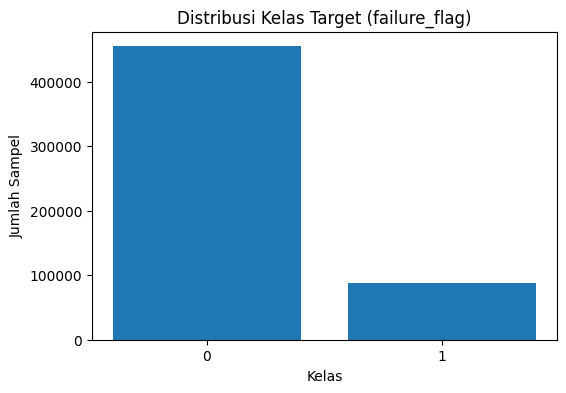

In [6]:
# Visualisasi imbalance target
plt.figure(figsize=(6, 4))
target_counts = clean_df["failure_flag"].value_counts().sort_index()
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title("Distribusi Kelas Target (failure_flag)")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")
plt.show()

## 3) Seleksi Fitur dan Analisis Korelasi

Kolom identitas dan kolom turunan yang berpotensi leakage tidak dipakai untuk training model final.

Kolom leakage yang dikeluarkan dari training: ['location_id', 'suitability_score', 'stress_level']
Unique values categorical:
- soil_type: 9
- moisture_regime: 3
- thermal_regime: 3
- nutrient_balance: 3
- plant_category: 3


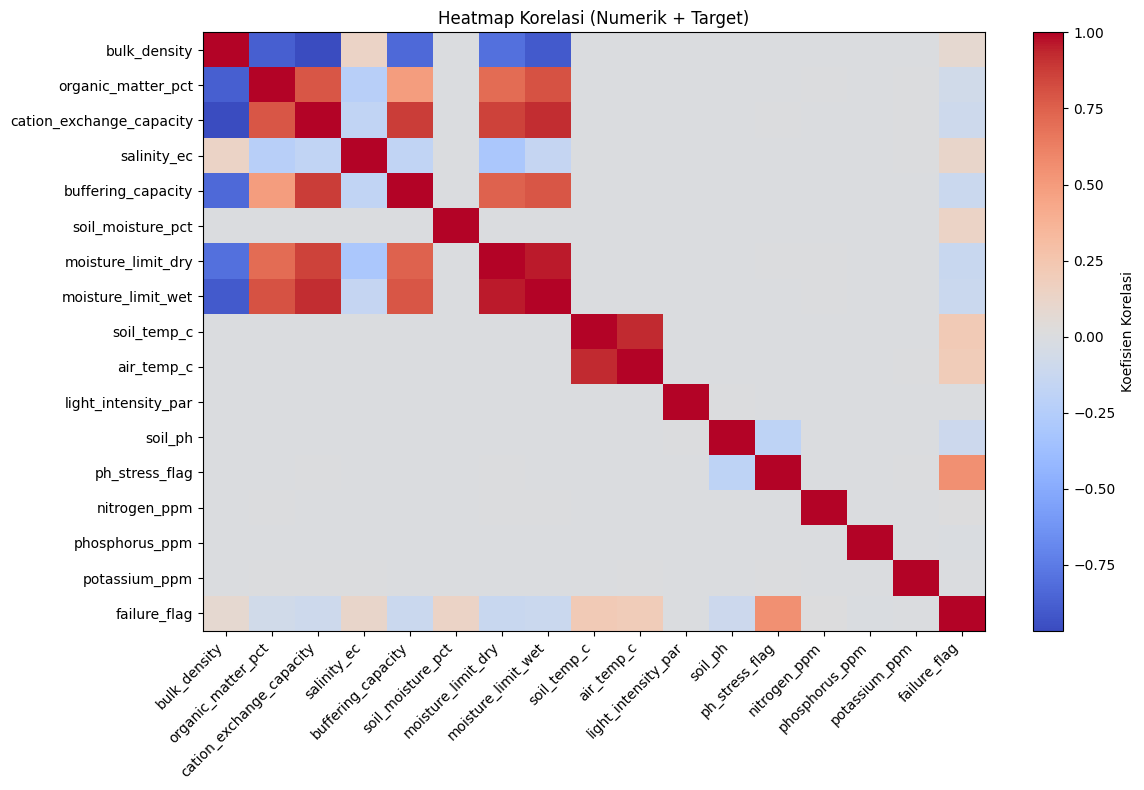

failure_flag                1.000000
ph_stress_flag              0.552076
soil_temp_c                 0.216402
air_temp_c                  0.201002
soil_moisture_pct           0.137044
salinity_ec                 0.116752
bulk_density                0.084758
nitrogen_ppm                0.009500
potassium_ppm               0.001123
light_intensity_par         0.000776
phosphorus_ppm             -0.009802
organic_matter_pct         -0.069632
cation_exchange_capacity   -0.097666
soil_ph                    -0.099133
buffering_capacity         -0.108961
moisture_limit_wet         -0.111998
moisture_limit_dry         -0.127956
Name: failure_flag, dtype: float64

In [7]:
target_col = "failure_flag"
selected_features = [
    "soil_type",
    "bulk_density",
    "organic_matter_pct",
    "cation_exchange_capacity",
    "salinity_ec",
    "buffering_capacity",
    "soil_moisture_pct",
    "moisture_limit_dry",
    "moisture_limit_wet",
    "moisture_regime",
    "soil_temp_c",
    "air_temp_c",
    "thermal_regime",
    "light_intensity_par",
    "soil_ph",
    "ph_stress_flag",
    "nitrogen_ppm",
    "phosphorus_ppm",
    "potassium_ppm",
    "nutrient_balance",
    "plant_category",
]

leakage_features = ["location_id", "suitability_score", "stress_level"]
model_df = clean_df[selected_features + [target_col]].copy()

numeric_features = [
    "bulk_density",
    "organic_matter_pct",
    "cation_exchange_capacity",
    "salinity_ec",
    "buffering_capacity",
    "soil_moisture_pct",
    "moisture_limit_dry",
    "moisture_limit_wet",
    "soil_temp_c",
    "air_temp_c",
    "light_intensity_par",
    "soil_ph",
    "ph_stress_flag",
    "nitrogen_ppm",
    "phosphorus_ppm",
    "potassium_ppm",
]

categorical_features = ["soil_type", "moisture_regime", "thermal_regime", "nutrient_balance", "plant_category"]

print("Kolom leakage yang dikeluarkan dari training:", leakage_features)
print("Unique values categorical:")
for col in categorical_features:
    print(f"- {col}: {model_df[col].nunique(dropna=False)}")

corr_df = model_df[numeric_features + [target_col]].copy()
corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Koefisien Korelasi")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Heatmap Korelasi (Numerik + Target)")
plt.tight_layout()
plt.show()

corr[target_col].sort_values(ascending=False)

## 4) Split Data dan Pipeline Preprocessing

In [8]:
X = model_df[selected_features].copy()
y = model_df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Sampling dipakai supaya baseline CV dan tuning tetap cepat di dataset yang besar
train_size = min(120000, len(X_train))
X_train_model, _, y_train_model, _ = train_test_split(
    X_train,
    y_train,
    train_size=train_size,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

search_size = min(40000, len(X_train_model))
X_search, _, y_search, _ = train_test_split(
    X_train_model,
    y_train_model,
    train_size=search_size,
    random_state=RANDOM_STATE,
    stratify=y_train_model,
)

# CV ringan agar notebook tidak lama
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Menangani imbalance dengan class_weight
classes = np.unique(y_train_model)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_model)
class_weight_dict = {c: w for c, w in zip(classes, class_weights)}
print("Class weights:", class_weight_dict)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Train full shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train model shape:", X_train_model.shape, "Search shape:", X_search.shape)

Class weights: {0: 0.5967655308229397, 1: 3.0835646006783843}
Train full shape: (434568, 21) Test shape: (108642, 21)
Train model shape: (120000, 21) Search shape: (40000, 21)


## 5) Baseline Model + Cross-Validation

Baseline dihitung pada subset training yang lebih kecil supaya proses evaluasi cepat, tetapi tetap representatif.

In [9]:
baseline_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight=class_weight_dict))
])

baseline_scores = cross_val_score(baseline_pipe, X_train_model, y_train_model, cv=cv, scoring="f1", n_jobs=-1)
print("Baseline Logistic Regression CV F1 mean:", baseline_scores.mean())
print("Baseline Logistic Regression CV F1 std:", baseline_scores.std())

Baseline Logistic Regression CV F1 mean: 0.9166763795409794
Baseline Logistic Regression CV F1 std: 0.0023874464384411593


## 6) Hyperparameter Tuning (Randomized Search Ringan)

Pencarian parameter dilakukan pada subset stratified yang lebih kecil dari data training agar proses tuning tetap cepat, lalu parameter terbaik dipakai ulang pada data training yang lebih besar.

In [10]:
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, class_weight=class_weight_dict, n_jobs=-1))
])

param_dist = {
    "model__n_estimators": [80, 120, 150],
    "model__max_depth": [None, 8, 12],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_dist,
    n_iter=4,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_search, y_search)
print("Best RF params:", rf_search.best_params_)
print("Best RF CV F1:", rf_search.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best RF params: {'model__n_estimators': 80, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best RF CV F1: 0.955091965218462


## 7) Ensemble Learning (Random Forest)

Random Forest dipakai sebagai model ensemble utama karena cepat, stabil, dan cocok untuk data campuran numerik serta kategorikal.

In [11]:
# Random Forest adalah ensemble utama yang dipilih untuk model final
final_model = rf_search.best_estimator_

# Fit ulang pada subset training yang lebih besar sebelum evaluasi test set
final_model.fit(X_train_model, y_train_model)

print("Model final:", final_model.named_steps["model"])
print("Best CV F1:", rf_search.best_score_)

Model final: RandomForestClassifier(class_weight={0: 0.5967655308229397,
                                     1: 3.0835646006783843},
                       n_estimators=80, n_jobs=-1, random_state=42)
Best CV F1: 0.955091965218462


## 8) Evaluasi Final di Test Set

In [14]:
y_pred = final_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1]) if hasattr(final_model, "predict_proba") else None

print("==============================")
print("HASIL EVALUASI RANDOM FOREST")
print("==============================")
print(f"Accuracy  : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"F1-score  : {f1:.4f}")
if roc_auc is not None:
    print(f"ROC-AUC   : {roc_auc:.4f}")
print("------------------------------")
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=["No Failure", "Failure"]))
print("Confusion matrix:")
print(pd.DataFrame(confusion_matrix(y_test, y_pred), index=["Actual No Failure", "Actual Failure"], columns=["Pred No Failure", "Pred Failure"]))

HASIL EVALUASI RANDOM FOREST
Accuracy  : 0.9864 (98.64%)
F1-score  : 0.9572
ROC-AUC   : 0.9975
------------------------------
Classification report:
              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99     91026
     Failure       0.98      0.94      0.96     17616

    accuracy                           0.99    108642
   macro avg       0.98      0.97      0.97    108642
weighted avg       0.99      0.99      0.99    108642

Confusion matrix:
                   Pred No Failure  Pred Failure
Actual No Failure            90666           360
Actual Failure                1115         16501


## 9) Simpan Model untuk Integrasi Aplikasi

In [13]:
model_path = "model/model.pkl"
joblib.dump(final_model, model_path)
print(f"Model berhasil disimpan ke: {model_path}")

Model berhasil disimpan ke: model/model.pkl
